In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, expon
import numpy as np
from tqdm import tqdm
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.metrics import silhouette_score
from sklearn.base import clone
from sklearn.manifold import TSNE
from matplotlib.ticker import MultipleLocator

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import PolynomialFeatures
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline 
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import plotly.express as px

### Task 1. Data description (3 points total)

Download and load the data, describe and summarize
them in a few sentences. Leading questions:
1. how many observations are there in the sample? Discuss the structure of the dataset:
how many quantitative and how many qualitative variables do we have? Are there any
missing data? (0.5 point)

2. Provide and describe appropriate frequency tables or descriptive statistics for the variables
(take into account the type of the variables!) (0.5 point).

3. Present and discuss (where appropriate) variables’ distributions, e.g.. compare them
with the normal, or other distribution by making histograms and plotting them together with a known
density function . (2 points)

In [357]:
data = pd.read_csv('earnings.csv', delimiter=';')
print("N observations:", len(data))
data.head()

N observations: 11000


,id,base,bonus,overtime_pay,other,sector,section_07,sex,education,contract,age,duration_total,duration_entity,duration_nominal,duration_overtime
0,192064,26651.53,0.0,0.00,0.00,1,3,2,4,1,49,33.03,7.06,1524.15,0.0
1,25495,40168.50,1500.0,0.00,3414.32,1,2,1,1,1,36,10.07,6.01,1562.40,0.0
2,142164,20134.80,0.0,0.00,1700.41,1,2,2,4,1,52,28.08,19.05,1816.00,0.0
3,198034,16475.00,0.0,0.00,1305.00,1,2,2,5,1,55,35.07,11.01,1816.00,0.0
4,144990,34797.60,0.0,1893.35,3118.73,1,2,2,2,1,50,27.00,19.01,722.80,63.0


In [358]:
data.describe()

,id,base,bonus,overtime_pay,other,sector,section_07,sex,education,contract,age,duration_total,duration_entity,duration_nominal,duration_overtime
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.00000,11000.000000,11000.000000,11000.000000
mean,99813.830182,33376.738065,2128.486176,1679.273923,2477.625815,1.041091,2.030091,1.753545,2.764182,1.154000,42.470182,18.56708,11.401382,1301.307435,47.702325
std,58047.974954,19276.551638,4966.444726,5407.964344,3715.419120,0.198510,0.682476,0.430966,1.230735,0.360965,10.012140,10.99695,9.322181,540.189234,111.963867
min,8.000000,10.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.000000,0.01000,0.010000,12.800000,0.000000
25%,49618.250000,20995.115000,0.000000,0.000000,0.000000,1.000000,2.000000,2.000000,2.000000,1.000000,34.000000,9.03000,3.070000,766.800000,0.000000
50%,99881.500000,31341.245000,620.000000,0.000000,2141.820000,1.000000,2.000000,2.000000,2.000000,1.000000,43.000000,19.03500,9.100000,1591.900000,0.000000
75%,149880.250000,41348.290000,2940.717500,1139.330000,3497.430000,1.000000,2.000000,2.000000,4.000000,1.000000,51.000000,27.11000,18.040000,1768.000000,40.000000
max,199986.000000,241624.390000,258061.000000,228110.340000,88555.760000,2.000000,3.000000,2.000000,6.000000,2.000000,77.000000,57.02000,46.010000,2024.000000,1812.580000


In [359]:
qualitative_cols = ['sector', 'section_07', 'sex', 'education', 'contract']
for col in qualitative_cols:
    print(data[col].value_counts().to_string(), '\n')

sector
1    10548
2      452 

section_07
2    5867
3    2732
1    2401 

sex
2    8289
1    2711 

education
2    6633
4    1983
5     906
3     680
1     430
6     368 

contract
1    9306
2    1694 



In [360]:
quantitative_cols = [
    'base',
    'bonus',
    'overtime_pay',
    'other',
    'age',
    'duration_total',
    'duration_entity',
    'duration_nominal',
    'duration_overtime'
]
data[quantitative_cols].describe()

,base,bonus,overtime_pay,other,age,duration_total,duration_entity,duration_nominal,duration_overtime
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.00000,11000.000000,11000.000000,11000.000000
mean,33376.738065,2128.486176,1679.273923,2477.625815,42.470182,18.56708,11.401382,1301.307435,47.702325
std,19276.551638,4966.444726,5407.964344,3715.419120,10.012140,10.99695,9.322181,540.189234,111.963867
min,10.000000,0.000000,0.000000,0.000000,19.000000,0.01000,0.010000,12.800000,0.000000
25%,20995.115000,0.000000,0.000000,0.000000,34.000000,9.03000,3.070000,766.800000,0.000000
50%,31341.245000,620.000000,0.000000,2141.820000,43.000000,19.03500,9.100000,1591.900000,0.000000
75%,41348.290000,2940.717500,1139.330000,3497.430000,51.000000,27.11000,18.040000,1768.000000,40.000000
max,241624.390000,258061.000000,228110.340000,88555.760000,77.000000,57.02000,46.010000,2024.000000,1812.580000


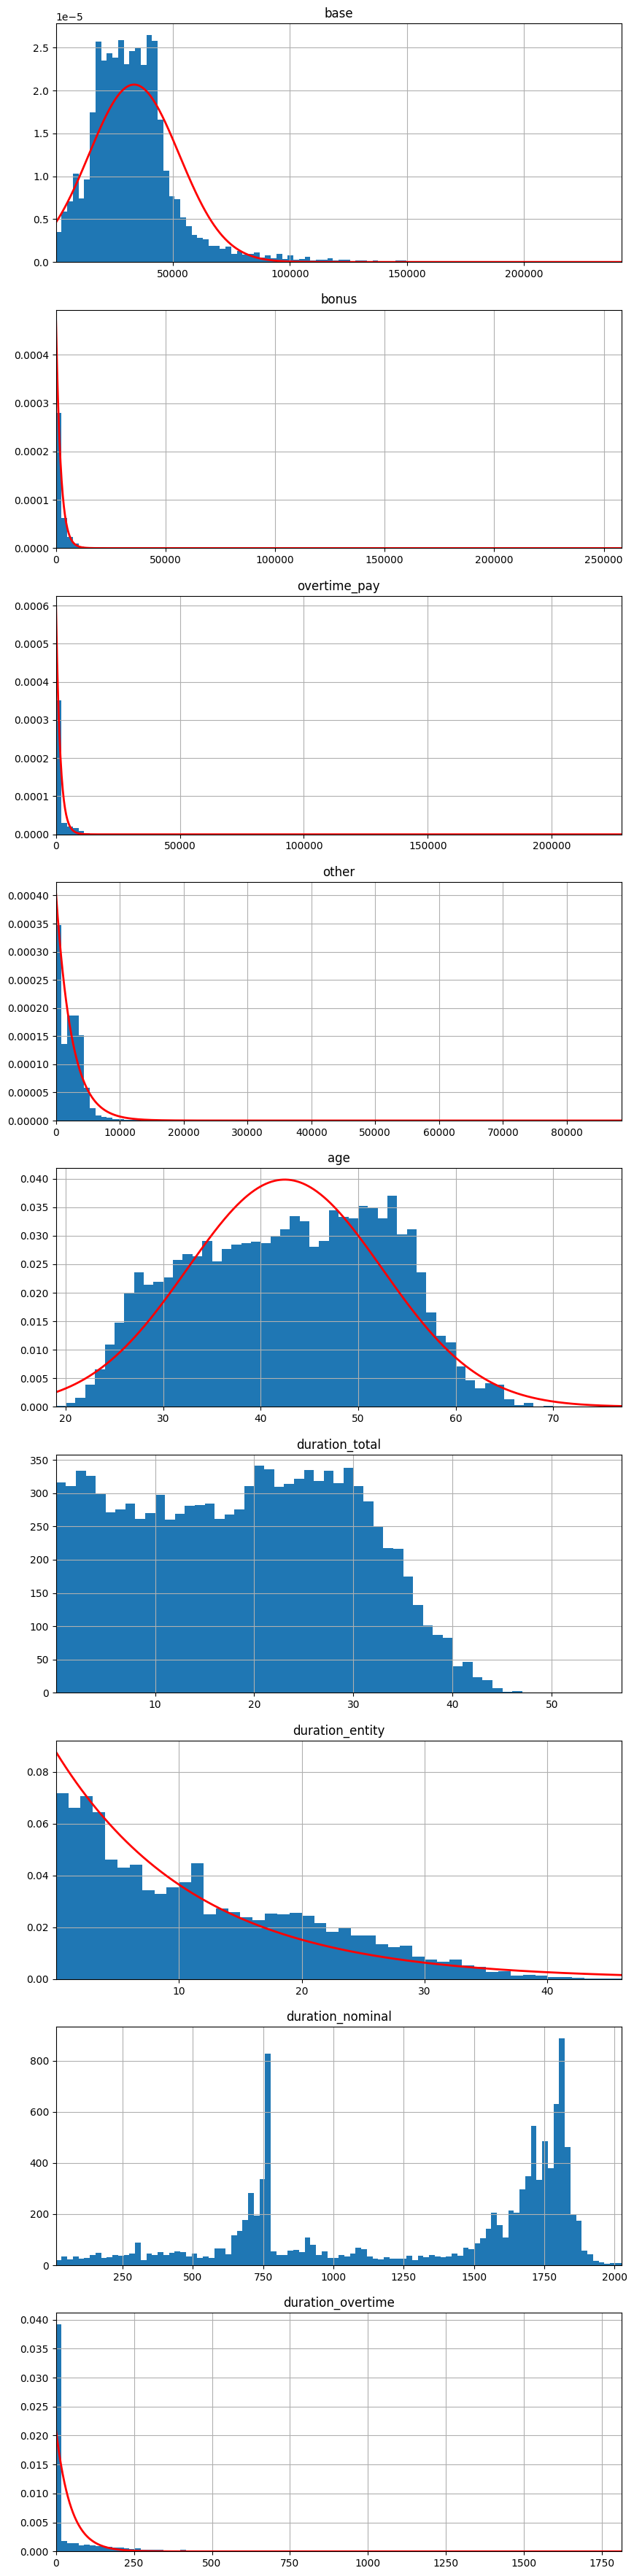

In [361]:
n_rows = len(quantitative_cols)

density = {
    'base': 'norm',
    'bonus': 'exp',
    'overtime_pay': 'exp',
    'other': 'exp',
    'age': 'norm',
    'duration_entity': 'exp',
    'duration_overtime': 'exp'
}


fig, axes = plt.subplots(len(quantitative_cols), 1, figsize=(10, 5 * n_rows))
for i, col in enumerate(quantitative_cols):
    x_min = data[col].min()
    x_max = data[col].max()
    x_values = np.linspace(x_min, x_max, 1000)

    axes[i].set_title(col)
    axes[i].set_xlim(x_min, x_max)
    
    if col not in density:
        data[col].hist(bins=min(100, int(x_max - x_min)), ax=axes[i], density=False)

    elif density[col] == 'norm':
        data[col].hist(bins=min(100, int(x_max - x_min)), ax=axes[i], density=True)
        
        mean = data[col].mean()
        std = data[col].std()

        y_values = norm.pdf(x_values, mean, std)
        axes[i].plot(x_values, y_values, color='red', lw=2, label='Normal PDF')
        
    elif density[col] == 'exp':
        data[col].hist(bins=min(100, int(x_max - x_min)), ax=axes[i], density=True)
        
        mean = data[col].mean()
        y_values = expon.pdf(x_values, scale=mean)
        axes[i].plot(x_values, y_values, color='red', lw=2, label='Exponential PDF')

    


Answers:
1. There are 11000 observations in the sample. 
There are 9 quantitative variables and 5 qualitative variables.
There is no missing data (count == 11000.000000 in the first describe table).

2. We can see a few interesting properties:

- there are much more women than men (8289 vs 2711)
- vast majority observations are from public sector (10548 vs 452)
- most of the observations have hihjer education
- most pepole work on for an indefinite period
- 25% didn't get any bonus and 50% didn't get any overtime payment
- oldest person is 77 yo

The distribution of all variabels seems to be reasonable.

3. Normal distribution on age is a bit of a stretch, but it is not that far from it. Variables where I didn't plot the distribution have their own internal structure that doesn't match any known distribution. 

### Task 2. Clustering (7 points total) 

Explore clustering of the samples. 

1. Using the clustering method of your choice and an appropriate distance measure to perform a clustering analysis of the data. (3 points) 

2. Describe your approach, in particular choice of variables and their transformations (coding, scaling), including justification of your choices. (2 points). 

3. Choose the optimal number of clusters based on the average silhouette score. (2 points)

Solution:

### 2.

I will delete features if they are strongly coreleated with each other.

From qualitative features I will only check 'education' as a candiadate for clustering. If a feature takes 1 or 2 values, it won't make much sense to use it.

In [392]:
cols = quantitative_cols + ['education']
cluster_data = data[cols].copy()

cluster_data.corr().abs()

,base,bonus,overtime_pay,other,age,duration_total,duration_entity,duration_nominal,duration_overtime,education
base,1.000000,0.211216,0.184220,0.370515,0.233965,0.248362,0.272979,0.274528,0.163426,0.334013
bonus,0.211216,1.000000,0.054103,0.050197,0.059364,0.074788,0.033600,0.237138,0.077111,0.006346
overtime_pay,0.184220,0.054103,1.000000,0.104176,0.007436,0.004601,0.054860,0.154939,0.865363,0.197116
other,0.370515,0.050197,0.104176,1.000000,0.122036,0.095526,0.124563,0.025624,0.115349,0.258311
age,0.233965,0.059364,0.007436,0.122036,1.000000,0.876186,0.549150,0.166100,0.014620,0.262583
duration_total,0.248362,0.074788,0.004601,0.095526,0.876186,1.000000,0.653426,0.240686,0.020661,0.302877
duration_entity,0.272979,0.033600,0.054860,0.124563,0.549150,0.653426,1.000000,0.156117,0.061260,0.123246
duration_nominal,0.274528,0.237138,0.154939,0.025624,0.166100,0.240686,0.156117,1.000000,0.235299,0.380781
duration_overtime,0.163426,0.077111,0.865363,0.115349,0.014620,0.020661,0.061260,0.235299,1.000000,0.235190
education,0.334013,0.006346,0.197116,0.258311,0.262583,0.302877,0.123246,0.380781,0.235190,1.000000


I drop 'duration_overtime' as it is strongly correlated with 'overtime_pay'. I also drop 'duration_total' as it is strongly correlated 'age'.

Now, I will choose features with high coefficient of variation. I drop with cv < 0.4

I will also log-transform exponential data and scale all data using Standard Scaler before clustering. This will make sure that all features are on the same scale and no feature is dominating the others.


In [393]:
cluster_data.drop(columns=['duration_overtime', 'duration_total'], inplace=True)

# calculate cv
cv = cluster_data.std() / cluster_data.mean()

cluster_data = cluster_data.loc[:, cv > 0.4]

cluster_data.head()

,base,bonus,overtime_pay,other,duration_entity,duration_nominal,education
0,26651.53,0.0,0.00,0.00,7.06,1524.15,4
1,40168.50,1500.0,0.00,3414.32,6.01,1562.40,1
2,20134.80,0.0,0.00,1700.41,19.05,1816.00,4
3,16475.00,0.0,0.00,1305.00,11.01,1816.00,5
4,34797.60,0.0,1893.35,3118.73,19.01,722.80,2


In [394]:
exp_cols = ['bonus', 'overtime_pay', 'other', 'duration_entity']

for col in exp_cols:
    cluster_data[col] = np.log1p(cluster_data[col])

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_data)
cluster_data = pd.DataFrame(scaled, columns=cluster_data.columns)

### 1 & 3

Now I will try some models and pick one with the best silhouette score. I use KMeans - it's fast, easy to use and had better results than Agglomerative clustering. DBSCAN is a bit irritating to use, because it doesn't classify the outliers so picking number of clusters is a bit tricky. 

100%|██████████| 68/68 [00:54<00:00,  1.24it/s]

Best number of clusters: 34
Best silhouette score: 0.30837620220355555


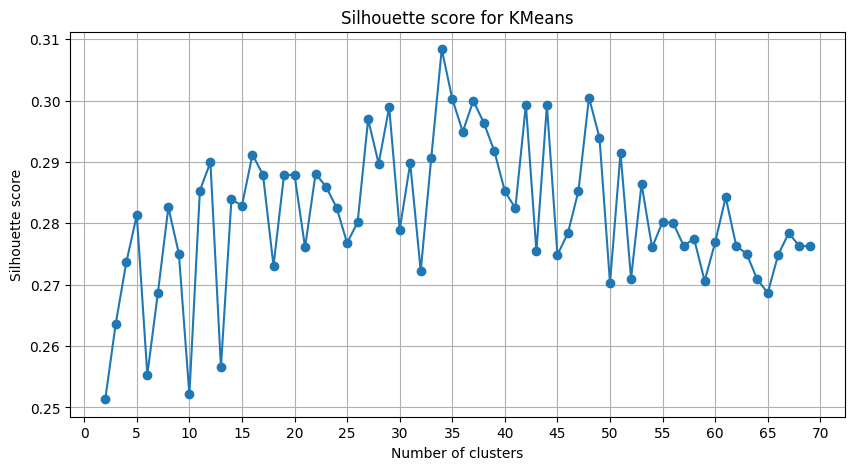

In [402]:
models = []
sils = []


def add_model(model):
    model.fit(cluster_data)
    models.append(model)
    y = model.labels_
    sil = silhouette_score(cluster_data, y)
    sils.append(sil)


min_cl, max_cl = 2, 70

for n_clusters in tqdm(range(min_cl, max_cl)):
    add_model(KMeans(n_clusters=n_clusters))


best_n_features = np.argmax(sils) + min_cl
best_kmeans = models[np.argmax(sils)]
print("Best number of clusters:", best_n_features)
print("Best silhouette score:", sils[np.argmax(sils)])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(min_cl, max_cl), sils, marker='o')
ax.set_title('Silhouette score for KMeans')
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Silhouette score')

ax.xaxis.set_major_locator(MultipleLocator(5)) # integers on x-axis

ax.grid()
plt.show()


I will visualize the clusters on a 2D plot (I reduce dimensionality with t-SNE).

In [404]:
tsne = TSNE(n_components=2)
cluster_data_2d = tsne.fit_transform(cluster_data)

best_model = models[sils.index(max(sils))]
labels = best_model.labels_

fig = px.scatter(
    x=cluster_data_2d[:, 0],
    y=cluster_data_2d[:, 1],
    color=labels
)
fig.show()

On 2d plot it makes some sense.

### Task 3. Classification (10 points total) 

1. Using the classification methods we have discussed, build a model that is predicting whether an employee has a higher education degree (education $\leq$ 2) based on the other data available. (4 points). 

2. Use cross-validation to assess the quality of your model ( 2 points) and provide an assessment of the expected performance on the data not seen in training (2 points). 

3. Evaluate the relative importance of different variables in the model you have constructed. (2 points),

Let's prepare data.

In [462]:
y = data['education'] <= 2
y = y.values.astype(np.float32)
X = data.drop(columns=['education', 'id'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

### 1
First, we can try a random forest classifier.

In [463]:
model = RandomForestClassifier()

cross_val = cross_val_score(model, X_train, y_train, cv=10)
print("Cross-validation score:", cross_val.mean())

Cross-validation score: 0.8804545454545456


### 2
The model is right almost 90% of the time in cross validation. Now we can check the performance on the test set (not seen in training).

In [464]:
model = RandomForestClassifier()

model.fit(X_train, y_train)


test_preds = model.predict(X_test)
train_preds = model.predict(X_train)
print("Test accuracy:", accuracy_score(y_test, test_preds))

Test accuracy: 0.89


### 3

Now we can check the importance of features.

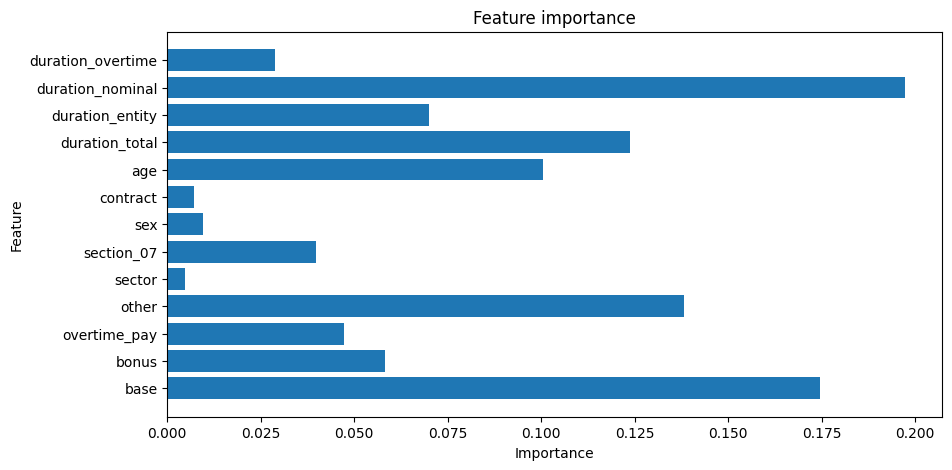

In [467]:
feature_importance = model.feature_importances_

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(X_train.columns, feature_importance)
ax.set_title('Feature importance')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.show()

### Task 4. Regression (10 points total) 

1. Using the regression methods we have discussed, build a regression model that predicts the base salary variable based on the other variables (4 points). 

2. Use appropriate methods to divide your data into training and testing subsets (2 points). Try to build a model that is not using unnecessary variables (2 points). 

3. Discuss the role (positive or negative) of all variables included in the model (2 points).